# 05 — Tool comparison: ViraLift (tblastn) vs LiftOn (Liftoff + miniprot)

**LiftOn** (Chao & Salzberg, *Genome Research* 2025;35(2):311) is the strongest modern baseline in
this space and the one closest in spirit to ViraLift: it runs **Liftoff (minimap2, DNA)** *and*
**miniprot (protein)**, chains the two to pick the best protein alignment per locus, and adds an ORF
search for truncated transcripts. Its thesis — DNA alignment alone is not enough, add protein
evidence — is the same insight ViraLift is built on, so this is the comparison a reviewer will ask
for. LiftOn's own benchmarks are entirely eukaryotic (human, mouse, honeybee, rice, *Arabidopsis*;
mouse↔rat, *D. melanogaster*↔*D. erecta*) — **no viral evaluation**, which is what this notebook adds.

### Metric — identical to `liftoff_compare.ipynb` and `gatu_50case_validate.ipynb`
Coordinate-only (IoU >= 0.90 **or** both boundaries within +-6 bp), codon check **off for both
tools**, truth-anchored denominator restricted to reference genes present in each record's truth
(`R ∩ truth`), duplicate truth names collapsed with `dedupe_truth_by_name`. See
`../VALIDATION_METHODOLOGY.md` and `CONSISTENCY_unit05.md`.

Both tools are leakage-free: LiftOn receives the target as a **sequence-only FASTA** plus the
reference GFF3 written from the reference bundle; ViraLift lifts from the **reference proteins**.
Neither sees the target's own annotation — only the scorer does.

### How to run
1. `pip install --no-deps lifton` then `pip install intervaltree duckdb pyarrow gffutils`
   (LiftOn pins `numpy==1.21.0`, which will not build on modern Python — hence `--no-deps`).
2. `minimap2` on PATH (`apt-get install minimap2`); build **miniprot** from
   `github.com/lh3/miniprot` and put it on PATH.
3. `tblastn` on PATH for ViraLift.
4. Run all cells. ~2 s per record for LiftOn on a 15 kb genome.

> ⚠️ `lifton -d` is a **distance scaling factor**, not an output directory. Passing a path there
> makes every lift silently fail — it cost one full run here before it was caught.

In [1]:
from pathlib import Path
import sys, subprocess, shutil, tempfile
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt, pandas as pd
from Bio import SeqIO
from app.validation._shared.validation_utils import *
from app.src.lifting.tblastn_lifter import lift_all_tblastn
from app.src.pipeline import PipelineConfig

OUTPUT_DIR = Path('outputs'); OUTPUT_DIR.mkdir(exist_ok=True)
CFG = PipelineConfig()   # production defaults, same as the accuracy harness
TOOL_COLORS = {'ViraLift': '#2f7d4f', 'LiftOn': '#3b6ea5'}

LIFTON   = shutil.which('lifton')
MINIPROT = shutil.which('miniprot')
MINIMAP2 = shutil.which('minimap2')
TBLASTN  = shutil.which('tblastn')
for name, path in (('lifton', LIFTON), ('miniprot', MINIPROT), ('minimap2', MINIMAP2), ('tblastn', TBLASTN)):
    print(f'{name:9s}:', path or 'NOT FOUND')
assert all((LIFTON, MINIPROT, MINIMAP2, TBLASTN)), 'Install the missing tool(s), then re-run.'
print('\nlifton version:', subprocess.run([LIFTON, '--version'], capture_output=True, text=True).stdout.strip()[-10:])

lifton   : /usr/local/bin/lifton
miniprot : /usr/local/bin/miniprot
minimap2 : /usr/bin/minimap2
tblastn  : /usr/bin/tblastn



lifton version: v1.0.11


In [2]:
# --- helpers (reference GFF3 writer is the same one liftoff_compare.ipynb uses) ---
def write_reference_gff(bundle, gff_path):
    """Reference annotation as GFF3, with CANONICAL gene names.

    The external tool therefore inherits the same names ViraLift assigns: name matching is not
    what is being tested here, coordinates are. Note every reference feature is written as a
    gene/mRNA/exon/CDS quartet regardless of whether the reference level is CDS (PRRSV, PEDV) or
    mat_peptide (FMDV) -- identical to the Liftoff notebook, so the two baselines see the same input.
    """
    ref_id = bundle['record'].id; lines = ['##gff-version 3']
    for f in bundle['features']:
        name, s, e, strand = f['name'], f['start'], f['end'], f['strand']
        g, t = f'gene-{name}', f'rna-{name}'
        lines += [
            f'{ref_id}\tviralift\tgene\t{s}\t{e}\t.\t{strand}\t.\tID={g};Name={name}',
            f'{ref_id}\tviralift\tmRNA\t{s}\t{e}\t.\t{strand}\t.\tID={t};Parent={g};Name={name}',
            f'{ref_id}\tviralift\texon\t{s}\t{e}\t.\t{strand}\t.\tID=exon-{name};Parent={t}',
            f'{ref_id}\tviralift\tCDS\t{s}\t{e}\t.\t{strand}\t0\tID=cds-{name};Parent={t};Name={name}',
        ]
    Path(gff_path).write_text('\n'.join(lines) + '\n')

def gff_to_rows(record_id, out_gff, method):
    agg = {}; p = Path(out_gff)
    if not p.exists(): return []
    for line in p.read_text().splitlines():
        if line.startswith('#') or not line.strip(): continue
        c = line.split('\t')
        if len(c) < 9 or c[2] != 'CDS': continue
        attrs = dict(kv.split('=', 1) for kv in c[8].split(';') if '=' in kv)
        name = attrs.get('Name') or attrs.get('Parent', '').replace('rna-', '')
        s, e, strand = int(c[3]), int(c[4]), c[6]
        if name not in agg: agg[name] = [s, e, strand]
        else: agg[name][0] = min(agg[name][0], s); agg[name][1] = max(agg[name][1], e)
    return [{'record_id': record_id, 'method': method, 'pred_name': n,
             'pred_start': v[0], 'pred_end': v[1], 'strand': v[2],
             'has_start_codon': None, 'has_stop_codon': None, 'in_frame': None}
            for n, v in agg.items()]

def run_lifton(ref_record, ref_fa, ref_gff, target_record, workdir):
    """One LiftOn run. NOTE: '-d' is a distance scaling factor, NOT a directory."""
    wd = Path(workdir); wd.mkdir(parents=True, exist_ok=True)
    tgt_fa, out_gff = wd / 'target.fa', wd / 'lifton.gff3'
    SeqIO.write(target_record, str(tgt_fa), 'fasta')
    proc = subprocess.run(
        [LIFTON, '-g', str(ref_gff), '-o', str(out_gff), '-u', str(wd / 'unmapped.txt'),
         '-t', '4', str(tgt_fa), str(ref_fa)],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, cwd=str(wd), check=False)
    return gff_to_rows(target_record.id, out_gff, 'lifton'), proc.returncode

def coverage_rows(virus, tool, acc, truth, preds):
    """Truth-anchored, coordinate-only (codon check OFF for both tools).
    One row per TRUTH gene: found = a same-name prediction is coordinate-correct."""
    if preds:
        cmp = compare_predictions_to_truth(preds, truth, codon_required_names=set())
        correct = set(cmp.loc[cmp['coord_correct'], 'pred_name']) if 'coord_correct' in cmp.columns else set()
        exact   = set(cmp.loc[cmp['exact_match'], 'pred_name']) if 'exact_match' in cmp.columns else set()
    else:
        correct, exact = set(), set()   # no prediction at all -> every truth gene is a miss
    return [{'virus': virus, 'tool': tool, 'accession': acc, 'gene': t['name'],
             'found': t['name'] in correct, 'exact': t['name'] in exact} for t in truth]

In [3]:
DATASETS = [
    ('PRRS', DATA / 'PRRS' / 'PRRS_ref_test.gb', DATA / 'PRRS' / 'PRRS_100seq_anno.gb'),
    ('FMD',  DATA / 'FMD'  / 'FMD_ref_test.gb',  DATA / 'FMD'  / 'FMD_100seq_anno.gb'),
    ('PED',  DATA / 'PED'  / 'PED_ref_1.gb',     DATA / 'PED'  / 'PED_100seqs.gb'),
]

cov, run_rows, detail, divergence = [], [], [], []
for virus, ref_path, query_path in DATASETS:
    bundle = load_reference_bundle(ref_path)
    validate_codons = bundle['feature_type'] == 'CDS'
    ref_names = sorted({f['name'] for f in bundle['features']})     # evaluable set R
    records = load_genbank_records(query_path)
    n_lifton_ok = 0
    with tempfile.TemporaryDirectory() as gdir:
        gdir = Path(gdir)
        ref_fa, ref_gff = gdir / 'ref.fa', gdir / 'ref.gff3'
        SeqIO.write(bundle['record'], str(ref_fa), 'fasta')
        write_reference_gff(bundle, ref_gff)
        for k, record in enumerate(records, 1):
            truth, _ = parse_truth_features(record, bundle['alias_lookup'], bundle['feature_type'],
                                            filter_nested=False, target_names=ref_names, keep_extra_names=[])
            truth = dedupe_truth_by_name(truth)
            if not truth: continue

            # LiftOn gets a sequence-only FASTA (SeqIO 'fasta' drops the annotation) + the ref GFF3
            l_preds, _ = run_lifton(bundle['record'], ref_fa, ref_gff, record, gdir / record.id)
            if l_preds: n_lifton_ok += 1

            v_lift = lift_all_tblastn(
                ref_features=bundle['features'], ref_record=bundle['record'], query_record=record,
                min_coverage=CFG.min_coverage, min_identity=CFG.min_identity,
                evalue=CFG.evalue, rescue_window=CFG.rescue_window,
                validate_codons=validate_codons)
            v_preds = lifted_to_rows(record.id, v_lift, 'viralift')

            cov += coverage_rows(virus, 'ViraLift', record.id, truth, v_preds)
            cov += coverage_rows(virus, 'LiftOn',   record.id, truth, l_preds)

            # divergence proxy: mean tblastn protein identity of this record vs the reference
            ids = [f.identity for f in v_lift if getattr(f, 'identity', None)]
            divergence.append({'virus': virus, 'accession': record.id,
                               'mean_protein_identity': round(sum(ids)/len(ids), 2) if ids else None,
                               'n_truth_genes': len(truth)})

            for tool, preds in (('ViraLift', v_preds), ('LiftOn', l_preds)):
                if not preds: continue
                d = compare_predictions_to_truth(preds, truth, codon_required_names=set())
                d = d[d['name_match']].copy(); d.insert(0, 'virus', virus); d.insert(1, 'tool', tool)
                detail.append(d)
            if k % 20 == 0: print(f'{virus}: {k}/{len(records)}')
    run_rows.append({'virus': virus, 'query_records': len(records),
                     'ref_feature_type': bundle['feature_type'],
                     'reference_genes': len(ref_names),
                     'records_lifton_produced_output': n_lifton_ok})

cov_df = pd.DataFrame(cov); cov_df.to_csv(OUTPUT_DIR / 'lifton_coverage_per_gene.tsv', sep='\t', index=False)
detail_df = pd.concat(detail, ignore_index=True) if detail else pd.DataFrame()
detail_df.to_csv(OUTPUT_DIR / 'lifton_per_feature.tsv', sep='\t', index=False)
div_df = pd.DataFrame(divergence); div_df.to_csv(OUTPUT_DIR / 'lifton_divergence.tsv', sep='\t', index=False)
pd.DataFrame(run_rows)

PRRS: 20/100


PRRS: 40/100


PRRS: 60/100


PRRS: 80/100


PRRS: 100/100


...

PED: 40/100


PED: 60/100


PED: 80/100


PED: 100/100


,virus,query_records,ref_feature_type,reference_genes,records_lifton_produced_output
0,PRRS,100,CDS,9,96
1,FMD,100,mat_peptide,12,98
2,PED,100,CDS,7,98


## Overall accuracy and buckets

Same three buckets as `02_lifting_accuracy` and the other unit-05 notebooks.

In [4]:
summary = (cov_df.groupby(['virus','tool'])
           .agg(truth_genes=('found','size'), correct=('found','sum')).reset_index())
summary['coord_pct'] = (summary['correct']/summary['truth_genes']*100).round(2)
summary.to_csv(OUTPUT_DIR / 'lifton_summary.tsv', sep='\t', index=False)

wide = summary.pivot(index='virus', columns='tool', values='coord_pct')
wide['ViraLift_minus_LiftOn'] = (wide['ViraLift'] - wide['LiftOn']).round(2)
wide.to_csv(OUTPUT_DIR / 'lifton_summary_wide.tsv', sep='\t')
print(summary.to_string(index=False)); print(); print(wide.to_string())

virus     tool  truth_genes  correct  coord_pct
  FMD   LiftOn         1172     1170      99.83
  FMD ViraLift         1172     1170      99.83
  PED   LiftOn          505      502      99.41
  PED ViraLift          505      504      99.80
 PRRS   LiftOn          796      759      95.35
 PRRS ViraLift          796      794      99.75

tool   LiftOn  ViraLift  ViraLift_minus_LiftOn
virus                                         
FMD     99.83     99.83                   0.00
PED     99.41     99.80                   0.39
PRRS    95.35     99.75                   4.40


In [5]:
b = cov_df.assign(bucket=lambda d: d.apply(
        lambda r: 'exact' if r['exact'] else ('coord_only' if r['found'] else 'failed'), axis=1))
buckets = (b.pivot_table(index=['virus','tool'], columns='bucket', values='gene',
                         aggfunc='size', fill_value=0)
             .reindex(columns=['exact','coord_only','failed'], fill_value=0))
buckets['total'] = buckets.sum(axis=1)
buckets['accuracy_pct'] = ((buckets['exact']+buckets['coord_only'])/buckets['total']*100).round(2)
buckets.to_csv(OUTPUT_DIR / 'lifton_buckets.tsv', sep='\t')
print(buckets.to_string())

exact_pg = (b.groupby(['virus','gene','tool'])['exact'].mean().mul(100).round(1).unstack('tool'))
exact_pg.to_csv(OUTPUT_DIR / 'lifton_exact_per_gene.tsv', sep='\t')
per_gene = (cov_df.groupby(['virus','gene','tool'])['found'].mean().mul(100).round(1).unstack('tool'))
per_gene.to_csv(OUTPUT_DIR / 'lifton_per_gene.tsv', sep='\t')
per_gene

bucket          exact  coord_only  failed  total  accuracy_pct
virus tool                                                    
FMD   LiftOn     1134          36       2   1172         99.83
      ViraLift   1138          32       2   1172         99.83
PED   LiftOn      497           5       3    505         99.41
      ViraLift    500           4       1    505         99.80
PRRS  LiftOn      672          87      37    796         95.35
      ViraLift    706          88       2    796         99.75


tool         LiftOn  ViraLift
virus gene                   
FMD   2A       99.0     100.0
      2B      100.0     100.0
      2C      100.0     100.0
      3A      100.0      99.0
      3B      100.0     100.0
      3Cpro   100.0     100.0
      3Dpol   100.0     100.0
      Lpro    100.0     100.0
      VP1     100.0     100.0
      VP2      99.0      99.0
      VP3     100.0     100.0
      VP4     100.0     100.0
PED   E       100.0     100.0
      M       100.0     100.0
      N       100.0     100.0
      ORF1a   100.0     100.0
      ORF1b    87.5      87.5
      ORF3     97.8     100.0
      S       100.0     100.0
PRRS  ORF1a    93.5     100.0
      ORF1b    94.3      98.9
      ORF2a    96.0     100.0
      ORF2b    91.8      98.0
      ORF3     96.0     100.0
      ORF4     96.0     100.0
      ORF5     96.0     100.0
      ORF6     96.0     100.0
      ORF7     96.0     100.0

## Failure modes — "lifted the wrong span" vs "produced nothing"

Truth-anchored scoring counts an unmapped gene as incorrect (methodology §5). Splitting the two
apart matters: for a DNA-seeded tool the interesting failure is usually *silence*, not misplacement.
It is also the only way to detect a **capability gap** — e.g. a tool that cannot express
`mat_peptide` features at all will show up here as near-total non-emission on FMDV.

In [6]:
emitted = set(zip(detail_df['virus'], detail_df['tool'],
                  detail_df['record_id'], detail_df['pred_name'])) if not detail_df.empty else set()
cov_df['emitted'] = [(r.virus, r.tool, r.accession, r.gene) in emitted for r in cov_df.itertuples()]

fm = cov_df.groupby(['virus','tool']).agg(truth_genes=('found','size')).reset_index()
ne = cov_df[~cov_df['emitted']].groupby(['virus','tool']).size()
wc = cov_df[~cov_df['found'] & cov_df['emitted']].groupby(['virus','tool']).size()
fm['not_emitted'] = [int(ne.get((r.virus, r.tool), 0)) for r in fm.itertuples()]
fm['wrong_coords'] = [int(wc.get((r.virus, r.tool), 0)) for r in fm.itertuples()]
fm['not_emitted_pct'] = (fm['not_emitted']/fm['truth_genes']*100).round(2)
fm.to_csv(OUTPUT_DIR / 'lifton_failure_modes.tsv', sep='\t', index=False)
print(fm.to_string(index=False))
print('\nrecords for which LiftOn produced any output:')
print(pd.DataFrame(run_rows).to_string(index=False))

virus     tool  truth_genes  not_emitted  wrong_coords  not_emitted_pct
  FMD   LiftOn         1172            1             1             0.09
  FMD ViraLift         1172            0             2             0.00
  PED   LiftOn          505            0             3             0.00
  PED ViraLift          505            0             1             0.00
 PRRS   LiftOn          796           35             2             4.40
 PRRS ViraLift          796            0             2             0.00

records for which LiftOn produced any output:
virus  query_records ref_feature_type  reference_genes  records_lifton_produced_output
 PRRS            100              CDS                9                              96
  FMD            100      mat_peptide               12                              98
  PED            100              CDS                7                              98


In [7]:
# per-miss detail: a cluster of identical deltas = boundary CONVENTION, not mislocation
if not detail_df.empty:
    miss = detail_df[~detail_df['coord_correct']].copy()
    cols = ['virus','tool','record_id','pred_name','pred_start','pred_end','truth_start','truth_end',
            'delta_start','delta_end','pred_minus_truth_len','iou','failure_mode']
    miss[cols].sort_values(['virus','tool','pred_name','record_id']).to_csv(
        OUTPUT_DIR / 'lifton_failure_detail.tsv', sep='\t', index=False)
    print(f'{len(miss)} misses among emitted predictions -> lifton_failure_detail.tsv')
    print(miss.groupby(['virus','tool','pred_name'])
              .agg(n=('iou','size'), iou_med=('iou','median'),
                   dstart_med=('delta_start','median'), dend_med=('delta_end','median'))
              .query('n >= 3').to_string())

11 misses among emitted predictions -> lifton_failure_detail.tsv
Empty DataFrame
Columns: [n, iou_med, dstart_med, dend_med]
Index: []


## ORF1b — do the two protein-aware tools agree on the frameshift convention?

PRRSV ORF1b is a −1 ribosomal frameshift product with no independent ATG, so where its 5' boundary
is declared is a lab convention. If LiftOn and ViraLift land on the *same* offsets, that is external
corroboration that the convention — not detection — is what separates tools here.

In [8]:
if not detail_df.empty:
    o = detail_df[(detail_df['virus']=='PRRS') & (detail_df['pred_name']=='ORF1b')]
    if len(o):
        print('ORF1b delta_start distribution (bp), by tool:')
        print(o.groupby('tool')['delta_start'].value_counts().unstack(fill_value=0).to_string())
        print('\nORF1b delta_end (0 everywhere = 3\' end always agrees):')
        print(o.groupby('tool')['delta_end'].value_counts().unstack(fill_value=0).to_string())

ORF1b delta_start distribution (bp), by tool:
delta_start  -75.0    -12.0    -9.0     -3.0      6.0      7493.0
tool                                                             
LiftOn             1       40        0       32       10        1
ViraLift           1       40        2       32       12        1

ORF1b delta_end (0 everywhere = 3' end always agrees):
delta_end  -5.0      0.0      4370.0
tool                                
LiftOn           1       82        1
ViraLift         0       87        1


## Accuracy vs divergence

The headline claim this notebook supports is **robustness at divergence**, not average accuracy.
`mean_protein_identity` is taken from ViraLift's own tblastn alignments (mean identity of that
record's lifted genes vs the reference) — a per-record divergence proxy that costs nothing extra.

In [9]:
dd = cov_df.merge(div_df, left_on=['virus','accession'], right_on=['virus','accession'], how='left')
dd = dd[dd['mean_protein_identity'].notna()]
bins = [0, 70, 80, 90, 95, 101]
labels = ['<70', '70-80', '80-90', '90-95', '>=95']
dd['identity_bin'] = pd.cut(dd['mean_protein_identity'], bins=bins, labels=labels, right=False)
by_div = (dd.groupby(['identity_bin','tool'], observed=True)
            .agg(truth_genes=('found','size'), correct=('found','sum')).reset_index())
by_div['accuracy_pct'] = (by_div['correct']/by_div['truth_genes']*100).round(2)
by_div.to_csv(OUTPUT_DIR / 'lifton_accuracy_by_divergence.tsv', sep='\t', index=False)
print(by_div.to_string(index=False))
print('\nrecords per identity bin:')
print(div_df.assign(identity_bin=pd.cut(div_df['mean_protein_identity'], bins=bins, labels=labels, right=False))
        .groupby(['identity_bin','virus'], observed=True).size().unstack(fill_value=0).to_string())

identity_bin     tool  truth_genes  correct  accuracy_pct
         <70   LiftOn           35        0          0.00
         <70 ViraLift           35       35        100.00
       70-80   LiftOn           60       60        100.00
       70-80 ViraLift           60       60        100.00
       80-90   LiftOn           95       95        100.00
       80-90 ViraLift           95       95        100.00
       90-95   LiftOn         1077     1075         99.81
       90-95 ViraLift         1077     1076         99.91
        >=95   LiftOn         1206     1201         99.59
        >=95 ViraLift         1206     1202         99.67

records per identity bin:
virus         FMD  PED  PRRS
identity_bin                
<70             0    0     4
70-80           5    0     0
80-90           0    0    12
90-95          47    1    64
>=95           46   97    20


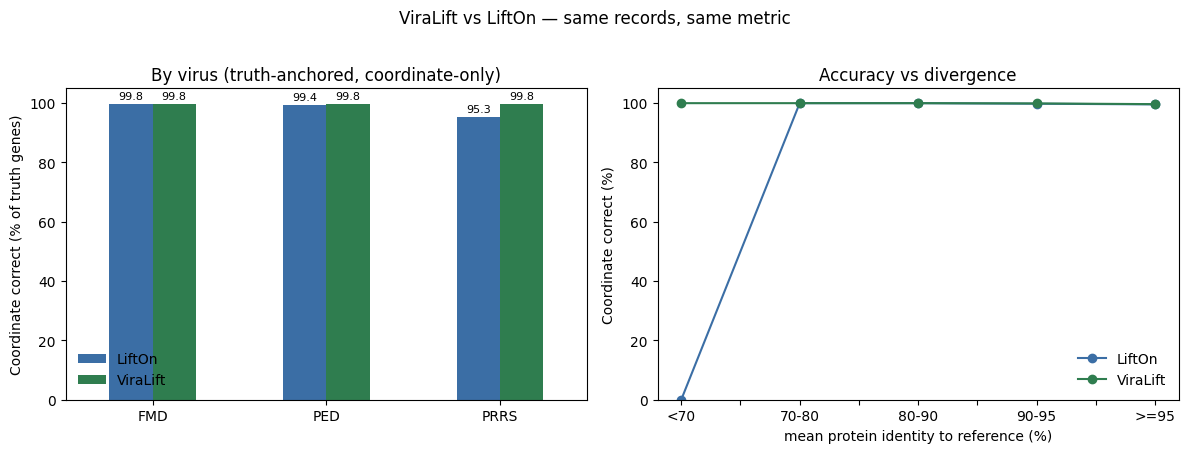

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

pv = summary.pivot(index='virus', columns='tool', values='coord_pct')[['LiftOn','ViraLift']]
pv.plot(kind='bar', ax=axes[0], color=[TOOL_COLORS['LiftOn'], TOOL_COLORS['ViraLift']], rot=0)
axes[0].set_ylim(0,105); axes[0].set_ylabel('Coordinate correct (% of truth genes)'); axes[0].set_xlabel('')
axes[0].set_title('By virus (truth-anchored, coordinate-only)'); axes[0].legend(frameon=False)
for c in axes[0].containers: axes[0].bar_label(c, fmt='%.1f', padding=2, fontsize=8)

pd_div = by_div.pivot(index='identity_bin', columns='tool', values='accuracy_pct')
pd_div = pd_div.reindex(columns=[c for c in ['LiftOn','ViraLift'] if c in pd_div.columns]).dropna(how='all')
pd_div.plot(kind='line', marker='o', ax=axes[1],
            color=[TOOL_COLORS[c] for c in pd_div.columns])
axes[1].set_ylim(0,105); axes[1].set_xlabel('mean protein identity to reference (%)')
axes[1].set_ylabel('Coordinate correct (%)'); axes[1].set_title('Accuracy vs divergence')
axes[1].legend(frameon=False)

fig.suptitle('ViraLift vs LiftOn — same records, same metric', y=1.02)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / 'lifton_accuracy.png', dpi=180, bbox_inches='tight')

## Interpretation

> Fill in after the run. Points to check explicitly:
> 1. **FMDV / `mat_peptide`** — did LiftOn emit mature peptides at all? Near-total non-emission in
>    `lifton_failure_modes.tsv` is a **capability gap**, and a much stronger paper point than a few
>    percent of accuracy. Do not assert it without this table.
> 2. **Within-genotype parity** — on high-identity records the two tools are expected to tie. Say so.
>    The claim is divergence robustness, not "more accurate than LiftOn".
> 3. **ORF1b** — if both tools share the delta_start distribution, cite it as external support that
>    GATU's ORF1b result is a convention artefact.